In [13]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud jupyter

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("data/raw/amazon_reviews.csv")

In [16]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [17]:
df.shape

(23486, 11)

In [18]:
df.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [20]:
df.describe(include="all")

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
count,23486.000000,23486.000000,23486.000000,19676,22641,23486.000000,23486.000000,23486.000000,23472,23472,23472
unique,NaN,NaN,NaN,13993,22634,NaN,NaN,NaN,3,6,20
top,NaN,NaN,NaN,Love it!,Perfect fit and i've gotten so many compliment...,NaN,NaN,NaN,General,Tops,Dresses
freq,NaN,NaN,NaN,136,3,NaN,NaN,NaN,13850,10468,6319
mean,11742.500000,918.118709,43.198544,NaN,NaN,4.196032,0.822362,2.535936,NaN,NaN,NaN
std,6779.968547,203.298980,12.279544,NaN,NaN,1.110031,0.382216,5.702202,NaN,NaN,NaN
min,0.000000,0.000000,18.000000,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN
25%,5871.250000,861.000000,34.000000,NaN,NaN,4.000000,1.000000,0.000000,NaN,NaN,NaN
50%,11742.500000,936.000000,41.000000,NaN,NaN,5.000000,1.000000,1.000000,NaN,NaN,NaN
75%,17613.750000,1078.000000,52.000000,NaN,NaN,5.000000,1.000000,3.000000,NaN,NaN,NaN


In [21]:
df.sample(5)

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
11741,11741,1078,52,Adorable dress but poor quality :(,I just think this dress is so cute! i love it ...,3,0,1,General Petite,Dresses,Dresses
17263,17263,653,34,So long!!,"I am of average height, but these pants are so...",2,0,1,Initmates,Intimate,Lounge
15300,15300,1059,44,Love these throw back pants!,"I love clothes, and my mom raised me to look f...",5,1,0,General,Bottoms,Pants
4878,4878,1086,62,Exactly as pictured,This is a pretty tunic/dress that looks and fi...,4,1,2,General Petite,Dresses,Dresses
19801,19801,1096,62,Heartbroken,I just received this beautiful dress in the ma...,3,1,4,General,Dresses,Dresses


# Day 1

## Objective
Understand the dataset and explore its structure.

### Tasks Completed
- Imported libraries
- Loaded dataset
- Viewed first few rows
- Checked dataset dimensions
- Examined columns and data types

In [22]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [23]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.nunique()

Unnamed: 0                 23486
Clothing ID                 1206
Age                           77
Title                      13993
Review Text                22634
Rating                         5
Recommended IND                2
Positive Feedback Count       82
Division Name                  3
Department Name                6
Class Name                    20
dtype: int64

In [26]:
df["Review Text"].head()

0    Absolutely wonderful - silky and sexy and comf...
1    Love this dress!  it's sooo pretty.  i happene...
2    I had such high hopes for this dress and reall...
3    I love, love, love this jumpsuit. it's fun, fl...
4    This shirt is very flattering to all due to th...
Name: Review Text, dtype: object

In [27]:
df["Rating"].value_counts()

Rating
5    13131
4     5077
3     2871
2     1565
1      842
Name: count, dtype: int64

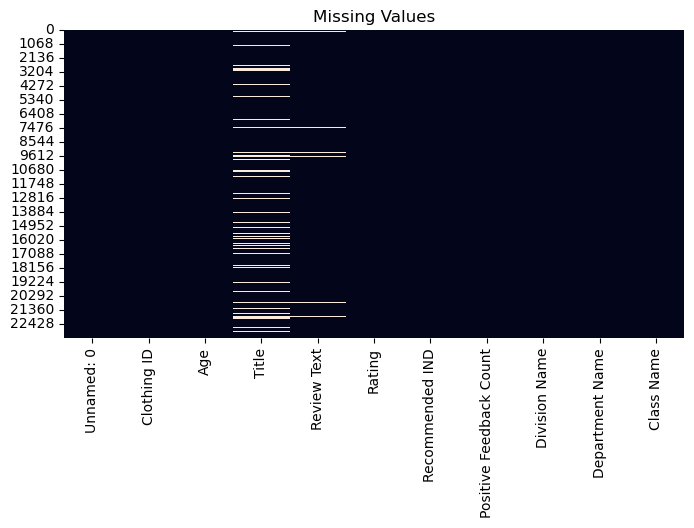

In [28]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

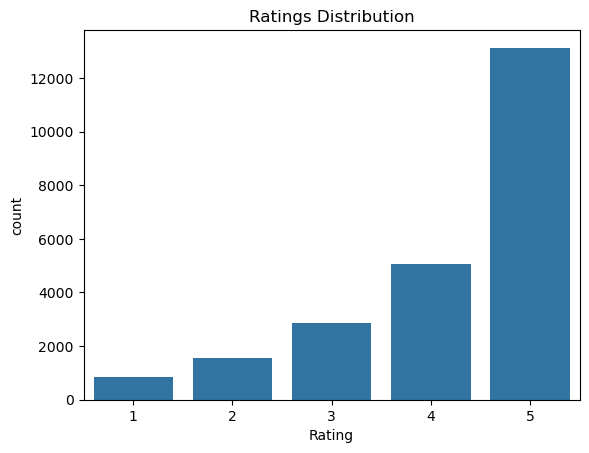

In [29]:
sns.countplot(x="Rating", data=df)
plt.title("Ratings Distribution")
plt.show()

# Day 2

## Objective
Understand data quality and identify potential issues.

### Tasks Completed
- Checked missing values
- Checked duplicates
- Counted unique values
- Examined review text
- Visualized rating distribution

# Customer Review Sentiment Analysis using NLP

## Author
Pooja Manjunath

## Objective
Build an end-to-end Sentiment Analysis model using Natural Language Processing and Machine Learning.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- NLTK
- Scikit-learn
- WordCloud

### Dataset
Amazon Customer Reviews Dataset

### Problem Statement
Businesses receive thousands of customer reviews daily. This project analyzes review text and predicts whether a review is Positive, Negative, or Neutral using NLP and Machine Learning techniques.

In [30]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [31]:
df = df.dropna()

In [32]:
df.isnull().sum()

Unnamed: 0                 0
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df = df.drop_duplicates()

In [35]:
df.dtypes

Unnamed: 0                  int64
Clothing ID                 int64
Age                         int64
Title                      object
Review Text                object
Rating                      int64
Recommended IND             int64
Positive Feedback Count     int64
Division Name              object
Department Name            object
Class Name                 object
dtype: object

In [36]:
df.to_csv("data/processed/cleaned_reviews.csv", index=False)

# Day 3

## Objective

Perform data cleaning.

### Tasks Completed

- Removed missing values
- Removed duplicate records
- Verified data types
- Saved cleaned dataset

In [37]:
import re
import string

In [38]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [39]:
df["Clean_Review"] = df["Review Text"].apply(clean_text)

In [40]:
df[["Review Text","Clean_Review"]].head()

,Review Text,Clean_Review
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit its fun flirty ...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...
5,"I love tracy reese dresses, but this one is no...",i love tracy reese dresses but this one is not...
6,I aded this in my basket at hte last mintue to...,i aded this in my basket at hte last mintue to...


# Day 4

## Objective

Clean customer review text.

### Tasks Completed

- Converted text to lowercase
- Removed punctuation
- Removed numbers
- Removed URLs
- Removed HTML tags

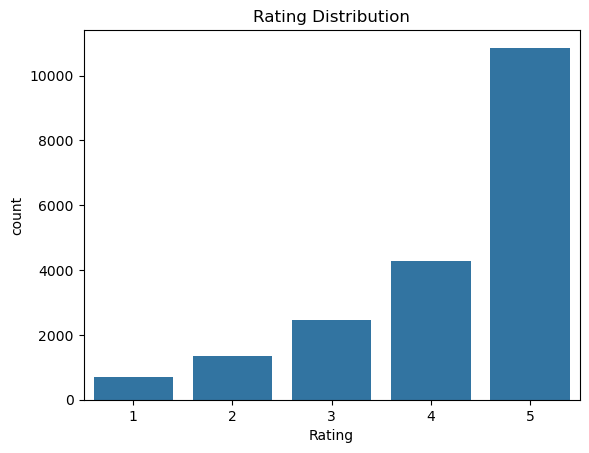

In [41]:
sns.countplot(x="Rating", data=df)
plt.title("Rating Distribution")
plt.show()

In [42]:
df["Review_Length"] = df["Clean_Review"].apply(len)

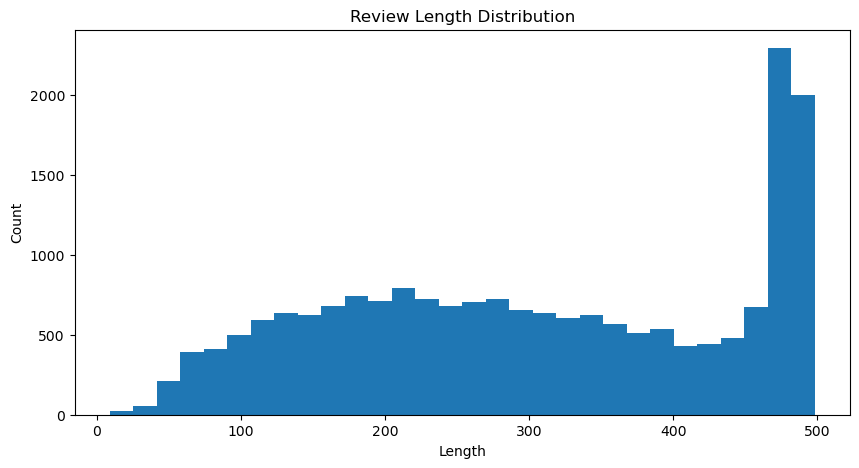

In [43]:
plt.figure(figsize=(10,5))
plt.hist(df["Review_Length"], bins=30)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [44]:
df["Rating"].value_counts()

Rating
5    10858
4     4289
3     2464
2     1360
1      691
Name: count, dtype: int64

# Day 5

## Objective

Perform exploratory data analysis.

### Tasks Completed

- Rating distribution
- Review length distribution
- Basic statistics

In [45]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [46]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [47]:
df["Tokens"] = df["Clean_Review"].apply(word_tokenize)

In [48]:
stop_words = set(stopwords.words("english"))

In [49]:
df["Filtered"] = df["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

# 

Day 6 - Tokenization and Stopword Removal

## Objective
Prepare the review text for machine learning by splitting text into words and removing common stopwords.

## Tasks Completed
- Downloaded NLTK resources
- Tokenized review text
- Removed stopwords
- Created filtered text for feature engineering

In [50]:
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [51]:


stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [52]:
import re
import string

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [53]:
df["Clean_Review"] = df["Review Text"].apply(clean_text)

In [54]:
from nltk.tokenize import word_tokenize

df["Tokens"] = df["Clean_Review"].apply(word_tokenize)

In [55]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["Filtered"] = df["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [62]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df["Stemmed"] = df["Filtered"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

In [63]:
from sklearn.feature_extraction.text import CountVectorizer

In [64]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [65]:
df["Stemmed"] = df["Filtered"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

In [66]:
df["Lemmatized"] = df["Filtered"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [67]:
df["Processed_Text"] = df["Lemmatized"].apply(lambda words: " ".join(words))

In [68]:
vectorizer = CountVectorizer(max_features=3000)

In [69]:
X = vectorizer.fit_transform(df["Processed_Text"])

In [70]:
X.shape

(19662, 3000)

# Day 8 - Bag of Words

## Objective

Convert cleaned text into numerical features using CountVectorizer.

### Tasks Completed

- Created processed text
- Applied Bag of Words
- Generated feature matrix

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [72]:
tfidf = TfidfVectorizer(max_features=3000)

In [73]:
X_tfidf = tfidf.fit_transform(df["Processed_Text"])

In [74]:
X_tfidf.shape

(19662, 3000)

# Day 9 - TF-IDF

## Objective

Convert text into weighted numerical vectors.

### Tasks Completed

- Applied TF-IDF
- Generated weighted feature matrix

In [75]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["Rating"].apply(sentiment_label)

In [117]:
from sklearn.model_selection import train_test_split

In [118]:
X = X_tfidf
y = df["Sentiment"]

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [120]:
from sklearn.naive_bayes import MultinomialNB

In [121]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [122]:
predictions = model.predict(X_test)

# Day 10 - First Machine Learning Model

## Objective

Train the first sentiment classification model.

### Tasks Completed

- Created sentiment labels
- Split dataset into training and testing sets
- Trained Naive Bayes model
- Generated predictions

In [123]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [124]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [125]:
predictions = model.predict(X_test)

In [85]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.7953216374269005


In [86]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    Negative       0.76      0.11      0.19       437
     Neutral       0.31      0.04      0.08       419
    Positive       0.80      1.00      0.89      3077

    accuracy                           0.80      3933
   macro avg       0.63      0.38      0.39      3933
weighted avg       0.75      0.80      0.72      3933



In [87]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[  48   31  358]
 [   9   18  392]
 [   6    9 3062]]


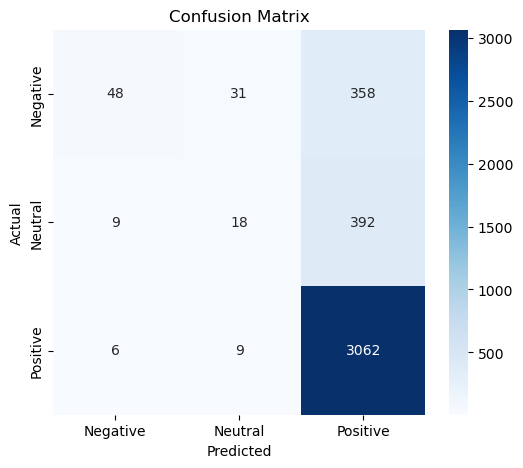

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Day 11 - Model Evaluation

## Objective

Evaluate the trained Naive Bayes model.

### Tasks Completed

- Calculated accuracy
- Generated classification report
- Created confusion matrix
- Visualized model performance

In [89]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [90]:
accuracy_score(y_test, lr_predictions)
classification_report(y_test, lr_predictions)
confusion_matrix(y_test, lr_predictions)

array([[ 180,  115,  142],
       [  68,  114,  237],
       [  29,   76, 2972]])

In [91]:

models = ["Naive Bayes", "Logistic Regression"]

accuracies = [
    accuracy_score(y_test, predictions),
    accuracy_score(y_test, lr_predictions)
]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

comparison

,Model,Accuracy
0,Naive Bayes,0.795322
1,Logistic Regression,0.830409


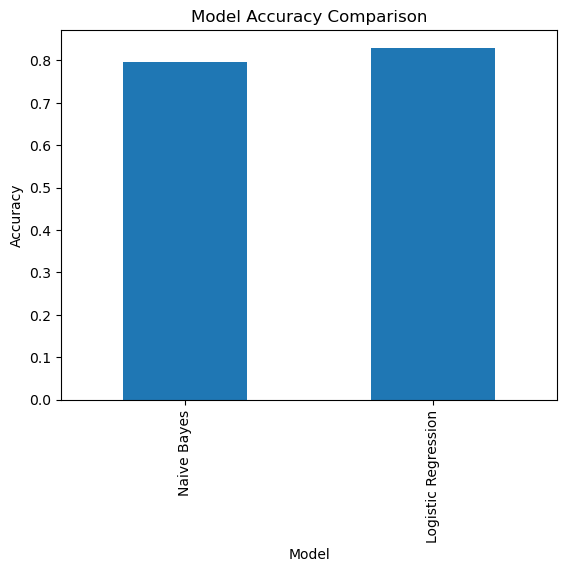

In [92]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    title="Model Accuracy Comparison"
)

plt.ylabel("Accuracy")
plt.show()

In [93]:
reviews = [
    "This dress is amazing",
    "Very poor quality",
    "Average product"
]

processed = tfidf.transform(reviews)

predictions = lr_model.predict(processed)

for review, sentiment in zip(reviews, predictions):
    print(review, "->", sentiment)

This dress is amazing -> Positive
Very poor quality -> Negative
Average product -> Negative


In [94]:
def get_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["Rating"].apply(get_sentiment)

In [95]:
df["Sentiment"].value_counts()

Sentiment
Positive    15147
Neutral      2464
Negative     2051
Name: count, dtype: int64

In [96]:
df.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name', 'Clean_Review', 'Review_Length',
       'Tokens', 'Filtered', 'Stemmed', 'Lemmatized', 'Processed_Text',
       'Sentiment'],
      dtype='object')

In [97]:
import re

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df["Processed_Text"] = df["Review Text"].apply(preprocess)

In [98]:
df[["Review Text", "Processed_Text"]].head()

,Review Text,Processed_Text
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit its fun flirty ...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...
5,"I love tracy reese dresses, but this one is no...",i love tracy reese dresses but this one is not...
6,I aded this in my basket at hte last mintue to...,i aded this in my basket at hte last mintue to...


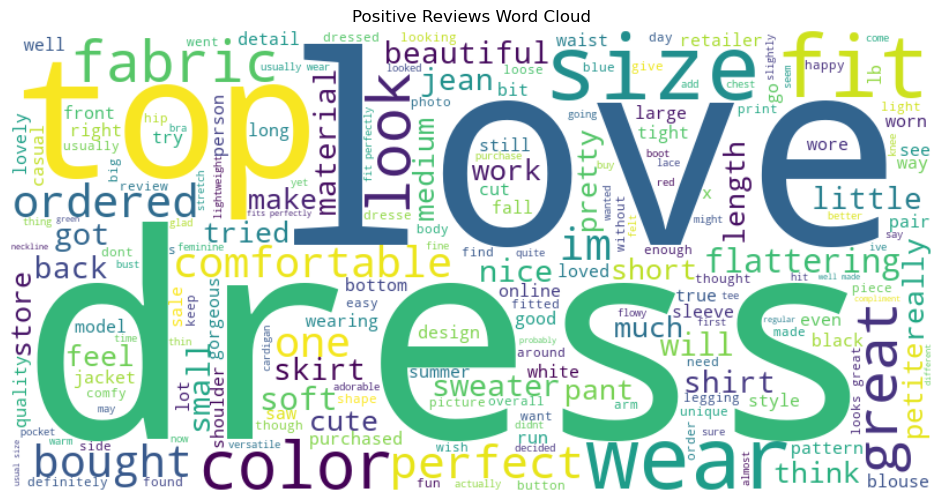

In [99]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_reviews = " ".join(
    df[df["Sentiment"] == "Positive"]["Processed_Text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

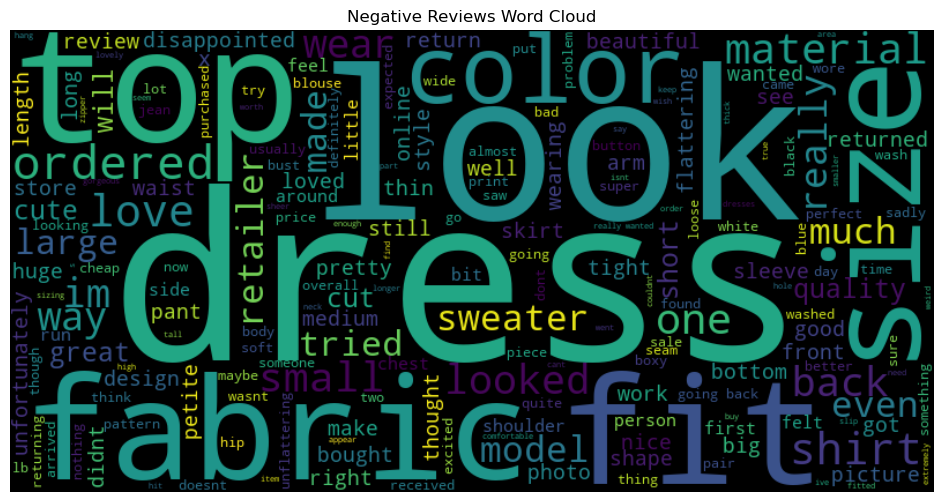

In [100]:
negative_reviews = " ".join(
    df[df["Sentiment"] == "Negative"]["Processed_Text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="black"
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Processed_Text"])

y = df["Sentiment"]

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [104]:
import pickle

with open("models/logistic_model.pkl", "wb") as file:
    pickle.dump(lr_model, file)

In [105]:
with open("models/vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

In [106]:
import os

os.listdir("models")

['logistic_model.pkl', 'vectorizer.pkl']

# Day 17 - Sentiment Prediction Function

## Objective

Build a reusable function to predict sentiment for new customer reviews.

### Tasks Completed

- Loaded saved model
- Loaded TF-IDF vectorizer
- Built prediction function
- Tested custom reviews

In [107]:
import pickle

with open("models/logistic_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("models/vectorizer.pkl", "rb") as file:
    vectorizer = pickle.load(file)

In [108]:
def predict_sentiment(review):
    review = review.lower()
    review_vector = vectorizer.transform([review])
    prediction = loaded_model.predict(review_vector)
    return prediction[0]

In [109]:
reviews = [
    "This dress is beautiful",
    "Worst quality product",
    "Average quality",
    "Excellent fitting and comfortable",
    "I hate this product"
]

for review in reviews:
    print(review)
    print("Prediction:", predict_sentiment(review))
    print("-"*40)

This dress is beautiful
Prediction: Positive
----------------------------------------
Worst quality product
Prediction: Negative
----------------------------------------
Average quality
Prediction: Positive
----------------------------------------
Excellent fitting and comfortable
Prediction: Positive
----------------------------------------
I hate this product
Prediction: Negative
----------------------------------------


In [111]:
review = input("Enter your review: ")

print("Predicted Sentiment:", predict_sentiment(review))

Enter your review:  good


Predicted Sentiment: Positive


# Day 18 - Feature Importance

## Objective

Identify the most influential positive and negative words.

### Tasks Completed

- Extracted TF-IDF features
- Displayed top positive words
- Displayed top negative words
- Visualized important words

In [112]:
import numpy as np

In [113]:
feature_names = vectorizer.get_feature_names_out()

coefficients = loaded_model.coef_[0]

In [114]:
top_positive = np.argsort(coefficients)[-20:]

print("Top Positive Words")

for i in top_positive:
    print(feature_names[i], round(coefficients[i],3))

Top Positive Words
money 1.49
no 1.497
worst 1.501
return 1.534
bummed 1.535
bag 1.662
shapeless 1.713
bulky 1.717
was 1.769
horrible 1.781
looked 1.803
disappointing 1.862
not 1.884
huge 2.002
poor 2.03
unflattering 2.049
wanted 2.118
disappointed 2.243
awful 2.274
cheap 2.593


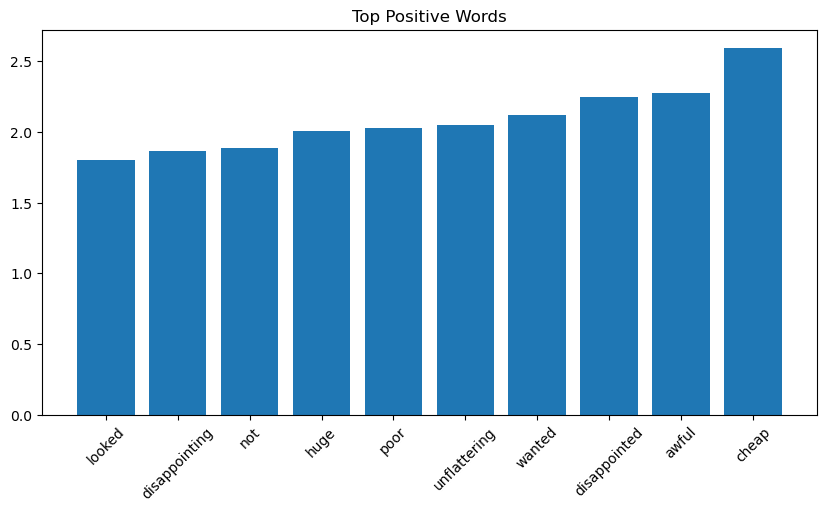

In [115]:
import matplotlib.pyplot as plt

top10 = np.argsort(coefficients)[-10:]

plt.figure(figsize=(10,5))

plt.bar(feature_names[top10], coefficients[top10])

plt.xticks(rotation=45)

plt.title("Top Positive Words")

plt.show()

# Day 19 - Model Performance Visualization

## Objective

Visualize the performance of Naive Bayes and Logistic Regression models.

### Tasks Completed

- Compared model accuracies
- Created bar chart
- Visualized Confusion Matrix
- Interpreted model performance

In [126]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, lr_predictions)
    ]
})

comparison

,Model,Accuracy
0,Naive Bayes,0.795322
1,Logistic Regression,0.830409


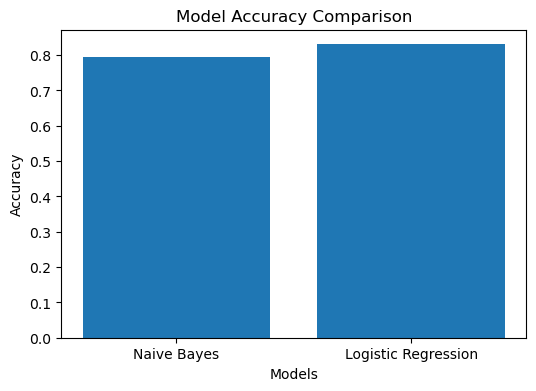

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

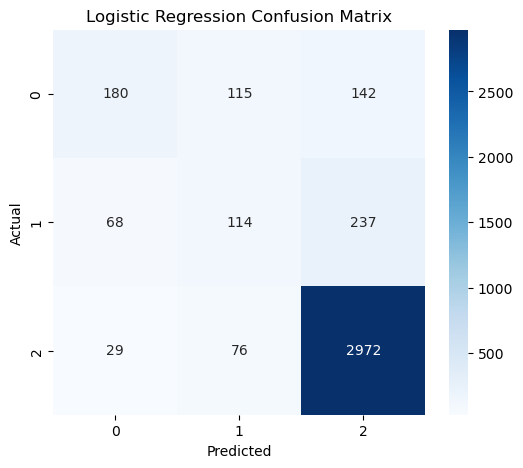

In [128]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

# Day 20 - Batch Sentiment Prediction

## Objective

Predict sentiment for multiple customer reviews.

### Tasks Completed

- Created review list
- Predicted sentiments
- Displayed results

In [129]:
customer_reviews = [

"This dress fits perfectly",

"The quality is terrible",

"Very comfortable and beautiful",

"I don't like this product",

"Average quality"

]

In [130]:
results = []

for review in customer_reviews:

    sentiment = predict_sentiment(review)

    results.append([review, sentiment])

results_df = pd.DataFrame(results,
                          columns=["Review",
                                   "Prediction"])

results_df

,Review,Prediction
0,This dress fits perfectly,Positive
1,The quality is terrible,Negative
2,Very comfortable and beautiful,Positive
3,I don't like this product,Negative
4,Average quality,Positive


In [131]:
results_df.to_csv("Predicted_Reviews.csv",
                  index=False)

In [132]:
import os

os.listdir()

['.git',
 '.gitignore',
 '.ipynb_checkpoints',
 'AI_Autonomous_Driving',
 'data',
 'images',
 'models',
 'Predicted_Reviews.csv',
 'README.md',
 'requirements.txt',
 'Sentiment_Analysis_Project.ipynb']

In [134]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

    Negative       0.65      0.41      0.50       437
     Neutral       0.37      0.27      0.31       419
    Positive       0.89      0.97      0.92      3077

    accuracy                           0.83      3933
   macro avg       0.64      0.55      0.58      3933
weighted avg       0.81      0.83      0.81      3933



In [135]:
import pickle

# Load saved model
with open("models/logistic_model.pkl", "rb") as file:
    model = pickle.load(file)

# Load saved TF-IDF vectorizer
with open("models/vectorizer.pkl", "rb") as file:
    tfidf = pickle.load(file)

In [137]:
review = input("Enter a customer review: ")

Enter a customer review:  This dress is very comfortable and beautiful


In [138]:
processed_review = tfidf.transform([review])

prediction = model.predict(processed_review)

print("Predicted Sentiment:", prediction[0])


Predicted Sentiment: Positive


# Day 21 - Interactive Sentiment Prediction

## Objective
Create an interactive interface for users to enter reviews and receive sentiment predictions.

## Tasks Completed
• Loaded saved Logistic Regression model
• Loaded saved TF-IDF vectorizer
• Accepted user review input
• Predicted sentiment
• Displayed result